### import libraries

In [ ]:
from foofit import *
import foofit

### necessary to plot data
%matplotlib notebook

import scipy
from scipy.ndimage import gaussian_filter1d

np.seterr(divide='ignore', invalid='ignore')

In [3]:
### layer0 is the one closest to ambient
params = Parameters()

params.add('numbLayers', value=1, vary=False)
params.add('wavelength', value=1, vary=False)

# params.add('I0', value=1, min = 0.8, max = 1.2, vary = True)
params.add('I0', value=1, vary = False)

params.add('bkg', value=0, vary=False)

params.add('pre_rho', value=0, vary=False)
params.add('pre_beta', value=0, vary=False)

params.add('layer0_dd', value=220, min=150, max=250, vary=True)
params.add('layer0_rho', value=0.2, min=0.2, max=0.28, vary=True)
params.add('layer0_sig', value=2,  min=0.5, max=10, vary=True)
params.add('layer0_beta', value=0, vary=False)

params.add('sub_rho', value=0.71, vary=False)
params.add('sub_sig', value=4, min=0.5, max=8, vary=True)
params.add('sub_beta', value=0, vary=False)

time for fit: 0.66 s
[[Fit Statistics]]
    # fitting method   = Powell
    # function evals   = 415
    # data points      = 135
    # variables        = 4
    chi-square         = 7.46811201
    reduced chi-square = 0.05700849
    Akaike info crit   = -382.775395
    Bayesian info crit = -371.154296
[[Variables]]
    numbLayers:   1 (fixed)
    wavelength:   1 (fixed)
    I0:           1 (fixed)
    bkg:          0 (fixed)
    pre_rho:      0 (fixed)
    pre_beta:     0 (fixed)
    layer0_dd:    222.116958 +/- 0.18144383 (0.08%) (init = 220)
    layer0_rho:   0.25284888 +/- 0.00599042 (2.37%) (init = 0.2)
    layer0_sig:   5.29974114 +/- 0.16476314 (3.11%) (init = 2)
    layer0_beta:  0 (fixed)
    sub_rho:      0.71 (fixed)
    sub_sig:      4.08265920 +/- 0.04982959 (1.22%) (init = 4)
    sub_beta:     0 (fixed)
[[Correlations]] (unreported correlations are < 0.100)
    C(layer0_rho, sub_sig)    = -0.686
    C(layer0_rho, layer0_sig) =  0.561
    C(layer0_sig, sub_sig)    = -0.279


<IPython.core.display.Javascript object>


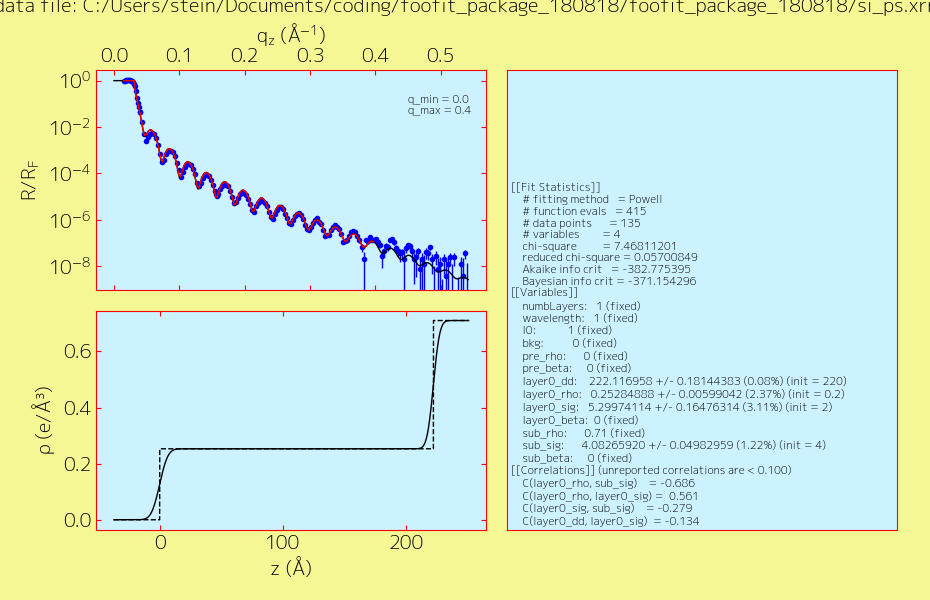

In [5]:
performFit('C:/Users/stein/Documents/coding/foofit_package_180818/foofit_package_180818/si_ps.xrr',
           params, 
           fitFunc = xrr_parratt_fit,
           method='powell',
           qmin = 0.00,
           qmax = 0.4,
           plot = 2,
           outputName = "bar2",
           weight = 2,
           rrfPlot = False,
           doConv = 0)

In [7]:
params2 = loadParams('bar2_2018-08-18_15.18.18_fit.fitParams', lowLim=0.3, highLim = 0.3)

<IPython.core.display.Javascript object>


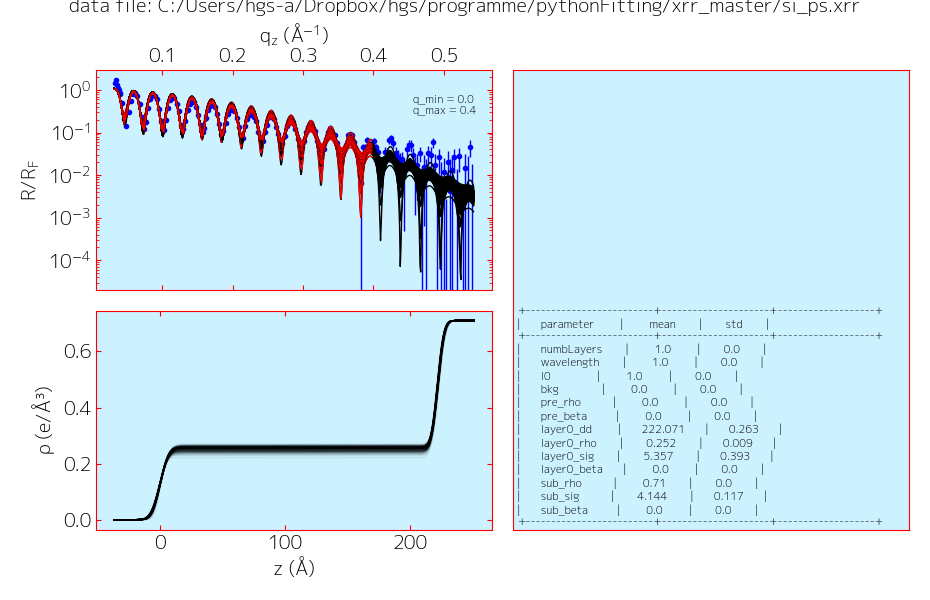

100%|██████████| 250/250 [00:02<00:00, 90.11it/s] 


In [10]:
performFit_mc('C:/Users/hgs-a/Dropbox/hgs/programme/pythonFitting/xrr_master/si_ps.xrr',
           params2, 
           fitFunc = xrr_parratt_fit,
           method='powell',
           qmin = 0.0,
           qmax = 0.4,
           outputName = "bar2",
           weight = 2,
           report = False,
           rrfPlot = True,
           NN = 250,
           doConv = 0.00)

<IPython.core.display.Javascript object>


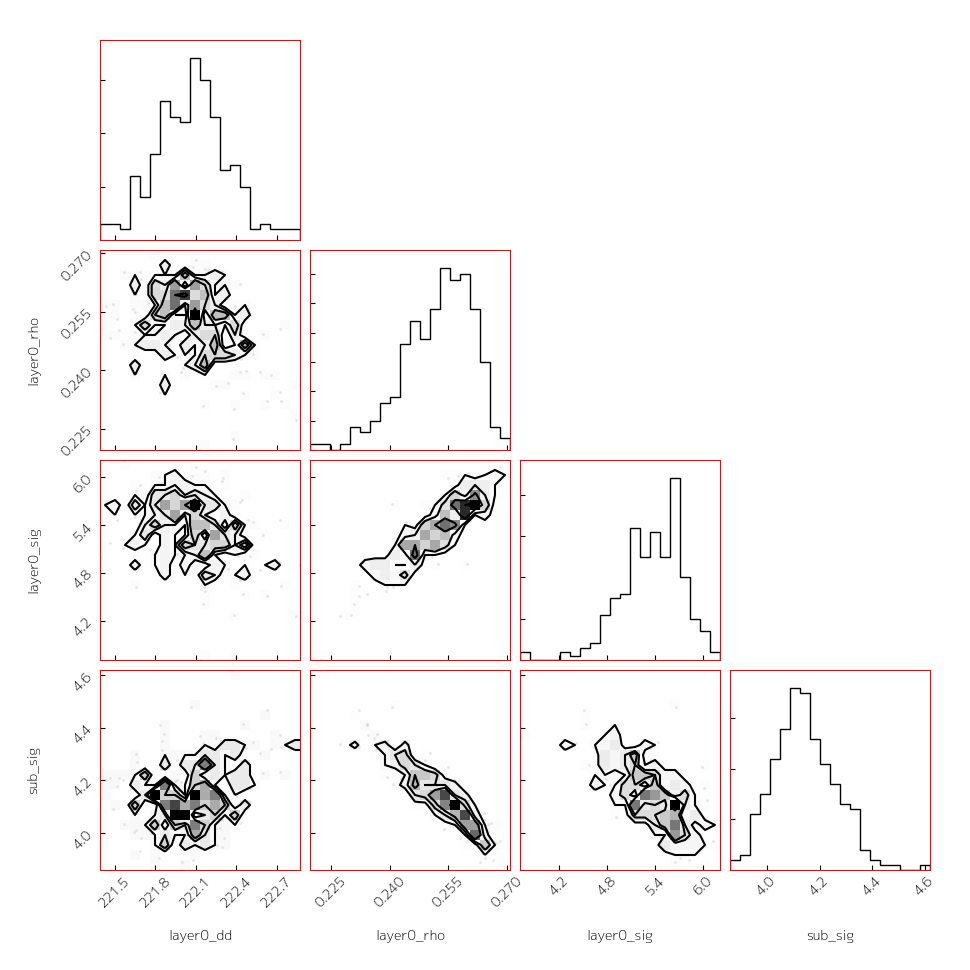

In [11]:
analyze_mc('bar2_2018-08-18_23.13.17_fit_mc.fitParams')